In [446]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

In [447]:
all_data = pd.read_csv('tables/zaModel.csv')
all_data = all_data.fillna(-1)

In [448]:
# izbacuje se jer naivni bajas ocekuje da su fature-i nezavisi, 
# a lap_length i num_of_laps imaju jaku korelaciju
all_data = all_data.drop('lap_length', axis=1)

In [449]:
#da se izbace prazna mesta iz imena kolona
all_data.columns = all_data.columns.str.strip()

#kategorijske i numericke kolone
categorical_cols = ['constructor', 'driverId', 'race_name',
                                'circuit']

numerical_cols = ['season', 'round', 'position_quali', 'grid',
                  'number_of_laps', 'number_of_corners', 
                  'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 
                  'WindSpeed', 'rain_bin', 'wind_direction', 
                  'last_year_time', 'avg_position_last5', 
                  'num_dnfs_last5', 'avg_gained_lost_last5',
                  'avg_pos_last5', 'avg_pit_duration_last5',
                  'avg_pit_duration_prev_race','avg_pit_duration_prev_driver_race', 
                  'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms']

#target kolona
target_col = 'position_race'

In [450]:
# all_data['points_true'] = all_data['position_race'].apply(lambda x: 1 if x >= 10 else 0)

In [451]:
#all_data = all_data.drop('position_race', axis=1)

In [452]:
y = all_data['position_race']

In [453]:
all_data = all_data.sort_values(by=["season", "round"]).reset_index(drop=True)

# uzima sve trke, bez ponavljanja
unique_races = all_data[["season", "round"]].drop_duplicates().reset_index(drop=True)
num_races = len(unique_races)

# velicina train, validacionog i test seta
train_size = int(num_races * 0.7)
test_size = num_races - train_size

In [454]:
test_size

45

In [455]:
X = all_data[categorical_cols + numerical_cols].copy()
y = all_data[target_col] 


# Split
X_train = X[:train_size * 20]
X_test = X[train_size * 20:]
y_train = y[:train_size * 20]
y_test = y[train_size * 20:]

In [456]:
# Label encoding kategorijskih feature-a
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
oe.fit(X_train[categorical_cols])
X_test.loc[:, categorical_cols] = oe.transform(X_test[categorical_cols])
X_train.loc[:, categorical_cols] = oe.transform(X_train[categorical_cols])



In [457]:
for col in categorical_cols:
    max_train = X_train[col].max()
    max_test = X_test[col].max()
    print(f'{col}: train max = {max_train}, test max = {max_test}')


constructor: train max = 14.0, test max = 14.0
driverId: train max = 33.0, test max = 33.0
race_name: train max = 34.0, test max = 34.0
circuit: train max = 29.0, test max = 29.0


In [458]:
# Odvojeno treniranje za kategorijske i numericka feature
model_cat = MultinomialNB(alpha=50)
model_num = GaussianNB()

model_cat.fit(X_train[categorical_cols], y_train)
model_num.fit(X_train[numerical_cols], y_train)

# Kombinacija predikcija (log-probabilistički pristup)
log_prob_cat = model_cat.predict_log_proba(X_test[categorical_cols])
log_prob_num = model_num.predict_log_proba(X_test[numerical_cols])

# Saberi log-verovatnoće i uzmi najverovatniju klasu
combined_log_prob = log_prob_num + log_prob_cat 
# y_pred = np.argmax(combined_log_prob, axis=1)


In [459]:
combined_log_prob.shape

(900, 20)

In [460]:
import numpy as np

# Pretpostavimo da je y_pred oblika (num_races * num_drivers, num_classes)
num_drivers = 20
num_races = combined_log_prob.shape[0] // num_drivers

# Dodaj race_ids: 0,0,...,0 (20 puta), 1,1,...,1 (20 puta), itd.
race_ids = np.repeat(np.arange(num_races), num_drivers)


# Ranks po trci
ranks_pred = np.zeros((num_races, num_drivers), dtype=int)

for i in range(num_races):
    # Izaberi redove za trku i
    preds = combined_log_prob[i * num_drivers : (i + 1) * num_drivers]  # (20, 20)

    # Očekivana pozicija (weighted average)
    expected_pos = np.sum(np.exp(preds) * np.arange(1, 21), axis=1)  # (20,)

    # Rangiraj: manji expected_pos znači bolji plasman
    sorted_idx = expected_pos.argsort()
    driver_ranks = np.empty_like(sorted_idx)
    driver_ranks[sorted_idx] = np.arange(num_drivers)

    ranks_pred[i] = driver_ranks + 1


In [461]:
for i in range(len(ranks_pred)):
    print(ranks_pred[i])

[ 1  3 11 16 18  2  4  6  8 20  7 13 19 17  5  9 15 10 14 12]
[ 2 12 17 18  7  4  5  6 10 16  9 13  8  3 11 14  1 20 19 15]
[ 1 14  8 13  7  2 18 17  9 19  4 10 20 15  3 12 16  5 11  6]
[17  2 12 18  8  1 19 20 16  3  5  7  4 13  6 15 10 14  9 11]
[ 1  4  8 15 16  3 17 19 10  5 20 12  7  6  9 11  2 13 14 18]
[14  3  7 16  6  1 17 18 10  2  5 12  4 15  8 11  9 13 20 19]
[ 3 12  7 13 14  2 15 16 17  4  8 10  6  5  9 11  1 20 18 19]
[ 1  4  9 18  8  2 19  5 10  3  6 13 20 16  7 11 15 12 17 14]
[ 3  9 10 11 12  2 13 14  6  4 19  8 20  5  7 18  1 17 15 16]
[12  6 14 15 16  3 19  5  7  1  4 18  2 13 20  8 11  9 10 17]
[ 9 11 12 13  1 19 20  7  2  4 18  3 10 16  6  8  5 17 14 15]
[ 1  2 14 10 16 19 17  6  3  7 15  4 12 18  8  9  5 11 13 20]
[ 1  4 18  6  2 20  3 17 13  5 10 11  7 16 12 14 15  8 19  9]
[14 17 16  4  1 19 20 13  7  2  5 10  3 12  6  8 11 18 15  9]
[ 4 15  9  8  2 16  6 14 10  3  7 19  5 11 20 12  1 13 18 17]
[16 15 13 11 14 19 10 18  8  9  7  6  5 17  2 20 12  4  1  3]
[ 2  5  

In [462]:
# import numpy as np

# # Pretpostavljamo:
# # - y_pred.shape == (600, 20)
# # - race_ids: niz od 600 elemenata koji govori kojoj trci svaki red pripada (npr. [0,0,...,1,1,...])

# unique_races = np.unique(race_ids)
# num_races = len(unique_races)
# num_drivers = combined_log_prob.shape[1]

# # Kreiraćemo ranks_pred: (num_races, num_drivers), gde je rang za svakog vozača u trci
# ranks_pred = np.zeros((num_races, num_drivers), dtype=int)

# for i, race_id in enumerate(unique_races):
#     # Indeksi vozača u toj trci
#     indices = np.where(race_ids == race_id)[0]
    
#     # Uzimamo predikcije za tu trku
#     preds = combined_log_prob[indices]  # oblika (num_drivers, 20)

#     # Za svakog vozača uzimamo očekivanu poziciju (možeš i argmax ako želiš najverovatniju klasu)
#     expected_pos = np.sum(preds * np.arange(1, 21), axis=1)

#     # Pretvori u rangove: manja očekivana pozicija = bolji plasman
#     sorted_idx = expected_pos.argsort()
#     driver_ranks = np.empty_like(sorted_idx)
#     driver_ranks[sorted_idx] = np.arange(num_drivers)

#     ranks_pred[i] = driver_ranks


In [463]:
y_test = pd.DataFrame(y_test)


In [464]:
ranks_pred.shape

(45, 20)

In [465]:
y_test = y_test.to_numpy()

In [466]:
y_test = y_test.reshape(45, 20)

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import ndcg_score, root_mean_squared_error

ndcg_values = []
tau_list = []
spearman_list = []
rmse_list = []

num_races = ranks_pred.shape[0]  # broj trka

for i in range(num_races):
    # Uzmemo istu trku (20 vozača) iz pravih i predikcija
    true_scores = y_test[i]     # niz od 20 vrednosti (npr. rezultati)
    pred_scores = ranks_pred[i]   # niz od 20 vrednosti (predikcije)

    # Pretvori u rangove: veći skor = bolji rang = manji broj
    true_ranks = pd.Series(-true_scores).rank(method='min').values
    pred_ranks = pd.Series(-pred_scores).rank(method='min').values

    # Reshape u 2D niz za ndcg_score (1 trka, 20 vozača)
    true_ranks_2d = true_ranks.reshape(1, -1)
    pred_ranks_2d = pred_ranks.reshape(1, -1)

    # NDCG@10
    ndcg = ndcg_score(true_ranks_2d, pred_ranks_2d, k=10)
    ndcg_values.append(ndcg)

    # Kendall's Tau & Spearman (za rangove)
    tau, _ = stats.kendalltau(true_ranks, pred_ranks)
    spearman, _ = stats.spearmanr(true_ranks, pred_ranks)
    tau_list.append(tau)
    spearman_list.append(spearman)

    # RMSE rangova
    rmse = root_mean_squared_error(true_ranks, pred_ranks) 
    rmse_list.append(rmse)

# Izračun prosečnih vrednosti
avg_ndcg = np.mean(ndcg_values)
avg_tau = np.nanmean(tau_list)
avg_spearman = np.nanmean(spearman_list)
avg_rmse = np.mean(rmse_list)

print(f"Average NDCG@10: {avg_ndcg:.4f}")
print(f"Average Kendall's Tau: {avg_tau:.4f}")
print(f"Average Spearman: {avg_spearman:.4f}")
print(f"Average RMSE: {avg_rmse:.4f}")


Average NDCG@10: 0.6773
Average Kendall's Tau: 0.1301
Average Spearman: 0.1778
Average RMSE: 7.2700


In [468]:
pred_ranks.shape

(20,)

In [484]:
all_true_ranks = []
all_pred_ranks = []

for i in range(ranks_pred.shape[0]):
    true_scores = y_test[i]        # jedna trka
    pred_scores = ranks_pred[i]    # predikcija za tu trku

    true_rank = pd.Series(-true_scores.flatten()).rank(method='min').astype(int).values
    pred_rank = pd.Series(-pred_scores.flatten()).rank(method='min').astype(int).values

    all_true_ranks.append(true_rank)
    all_pred_ranks.append(pred_rank)

true_ranks = np.array(all_true_ranks)  # Oblik: (br_trka, 20)
pred_ranks = np.array(all_pred_ranks)


In [ ]:
# all_true_ranks = []
# all_pred_ranks = []

# for i in range(ranks_pred.shape[0]):
#     true_scores = y_test[i:i+20]
#     pred_scores = ranks_pred[i]

#     true_rank = pd.Series(-true_scores.flatten()).rank(method='min').astype(int).values
#     pred_rank = pd.Series(-pred_scores.flatten()).rank(method='min').astype(int).values

#     all_true_ranks.append(list(true_rank))
#     all_pred_ranks.append(list(pred_rank))

# # Sada imaš listu svih rangova po trci → napravi matricu
# true_ranks = np.array(all_true_ranks)  # Oblik: (br_trka, 20)
# pred_ranks = np.array(all_pred_ranks)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (45,) + inhomogeneous part.

In [485]:
all_true_ranks

[array([11, 18, 13,  7, 12, 16,  6,  8,  2, 20,  4,  3, 19,  1, 14, 17,  9,
        15, 10,  5]),
 array([ 2, 18,  3,  7, 12, 16,  9, 11, 14, 19,  4, 13, 20,  6, 17, 15,  5,
         1, 10,  8]),
 array([ 2, 18, 10,  6,  8, 19, 14,  4,  1, 20, 15,  7, 16, 13,  3,  9,  5,
        17, 11, 12]),
 array([ 9, 17,  3,  1,  7, 15,  4,  8, 18, 19, 12,  6, 20, 10, 13, 16,  5,
        14, 11,  2]),
 array([ 7, 18,  8,  3, 13, 15,  6, 11, 14, 20,  4, 12, 19,  2, 17, 16,  1,
         9, 10,  5]),
 array([ 7, 19, 10,  9, 14, 17,  4,  2, 15, 20, 12, 18,  5, 11, 16, 13,  3,
         1,  6,  8]),
 array([ 5, 14,  2,  7, 11, 19,  6,  3, 10, 20,  4, 13, 17,  8, 18, 16,  1,
        15,  9, 12]),
 array([14, 19, 11,  3,  9, 18,  6,  4, 17, 20,  8, 13, 15, 10,  2, 16,  1,
        12,  7,  5]),
 array([10, 16,  6,  4, 11, 13,  1,  3, 19, 20, 17,  7, 18,  5, 14, 15,  8,
        12,  2,  9]),
 array([13, 14,  9,  4,  3, 18,  8,  2, 12, 20, 19,  1, 15, 17, 16, 11, 10,
         7,  5,  6]),
 array([10, 12,  9, 

In [486]:
for i in range(all_true_ranks):
    len(all_true_ranks[i])

TypeError: 'list' object cannot be interpreted as an integer

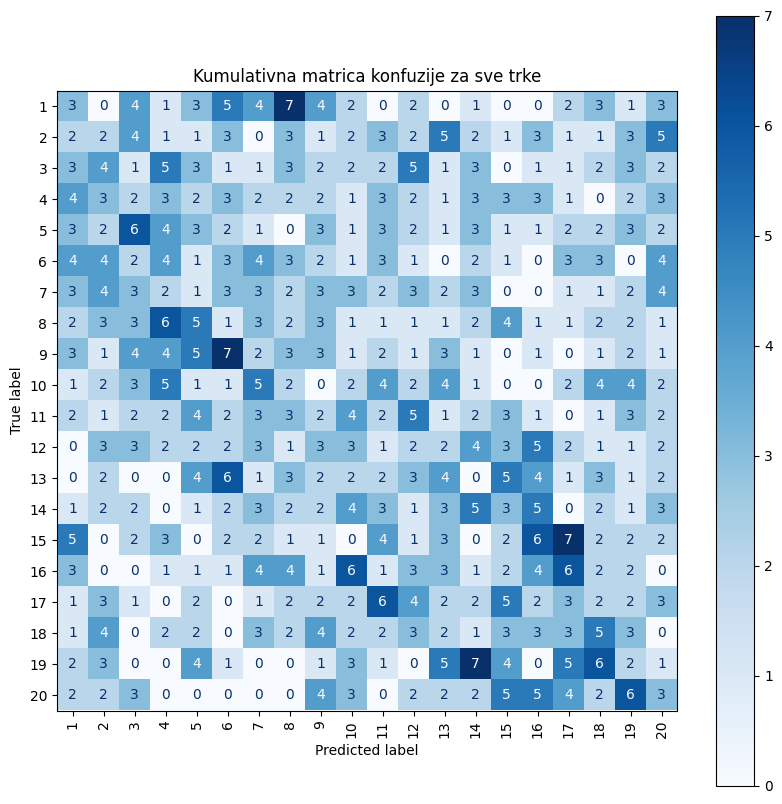

In [487]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Ako su rangovi po trci (oblik: [br_trka, 20])
# Spajamo sve u jedan vektor
y_true = true_ranks.flatten()
y_pred = pred_ranks.flatten()

# Kreiramo konfuzionu matricu
cm = confusion_matrix(y_true, y_pred, labels=np.arange(1, 21))

# Prikaz matrice
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(1, 21))
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation='vertical')
plt.title("Kumulativna matrica konfuzije za sve trke")
plt.show()


In [473]:
true_ranks.flatten()

array([10., 12.,  3.,  2.,  6., 14., 17., 13.,  5.,  4., 18., 15., 20.,
        1., 11., 16., 19.,  7.,  9.,  8.])

In [472]:
y_pred

array([20., 17.,  4., 11.,  5., 13., 18., 15.,  1.,  3.,  8., 16., 10.,
       14., 19.,  9.,  2.,  7.,  6., 12.])